# Cactus pangenome panel — sequence-similarity QC and labeling cross-check

**Date:** 2026-05-15 · **Author:** Tatiana Bellagio (Carnegie / Exposito-Alonso lab)
**Source:** 82 long-read assemblies from `20260209_Exposito-Alonso/chr_only/` (Tübingen / Max Planck Tübingen, F. Rabanal).

## What this notebook does

We compute pairwise Chr1 FASTA k-mer Jaccard (k=31, canonical) on the raw long-read assemblies, then cross-check against 1001 Genomes short-read SNP data (GrENE-Net VCF, 231 ecotypes), and consolidate the findings with two metadata sources from Tübingen:

1. `ASSEMBLIES_Best_version_of_dataset.xlsx` (MAIN_LIST sheet) — contains `Wrong_Previous_Accession_*` columns documenting historical re-identifications.
2. `request_assemblies_for_Moi.csv` (Fernando Rabanal, 2026-05-14) — adds a `Best_for_Moi` column flagging assemblies he recommends excluding, with a `Reason` per row.

## Inputs and methodology (md5-verified to Tübingen MAIN_LIST)

- **FASTAs:** `20260209_Exposito-Alonso/chr_only/<Assembly_ID>.chr.fa`. md5 hashes of the chromosome-only files match Tübingen MAIN_LIST `md5sum_Chr_scaffolds` for all sampled IDs.
- **Manifest:** `data/sv_panel_to_accession_id.tsv` matches MAIN_LIST 1:1 across all 82 entries.
- **k-mer counting:** `jellyfish count -m 31 -C` on Chr1 of each raw FASTA. Pairwise Jaccard via `jellyfish merge`, with |A∩B| = |A| + |B| − |A∪B|, Jaccard = |A∩B| / |A∪B|.
- **1001G cross-validation:** GrENE-Net VCF (`greneNet_final_v1.1.recode.vcf`, 231 ecotypes, 827,765 Chr1 SNPs). Genotype-set Jaccard: positions where the accession carries the ALT allele; |both ALT| / |either ALT|, restricted to co-call positions.
- **Arapheno-double-ID translation for 1001G cross-validation:** Fernando confirmed (email 2026-05-14) that both arapheno entries for Ct-1 (6910 and 7067) and for No-0 (7275 and 7273) refer to the same biological samples; Tübingen semi-arbitrarily chose 6910 / 7275. For the 1001G lookup only, we therefore translate 6910 → 7067 and 7275 → 7273 so all 82 assemblies have a 1001G partner.

## Final classification — three categories

After consolidating Fernando's `Best_for_Moi` flags with our k-mer + 1001G analysis, the 82 assemblies split into three groups (full table in `data/flag_list.tsv`; exclude IDs in `data/exclude_list.txt`):

| Group | n | Display |
|---|---|---|
| **EXCLUDE** — Fernando-flagged + our analysis confirms anomaly | 1 | Axis label **red bold** |
| **FLAG (quality)** — Fernando `Best_for_Moi="?"` (heterozygosity or low ONT coverage) | 6 | Axis label **orange** |
| **FLAG (ambiguous pair)** — concordant anomalous closeness in both cactus and 1001G | 4 | Axis label **purple** |
| Clean | 71 | Axis label black |

| Assembly_ID | Accession | Group | Reason |
|---|---|---|---|
| **101003** | **Set-1 / 5772** | **EXCLUDE** | Fernando: `Heterozygosity: Too many variants`. Our analysis: cactus k-mer J=0.964 vs T980 (100954); 1001G J=0.300 — discordant. Heterozygous Set-1 assembly explains the inflated k-mer overlap. |
| 100395 | Kru-3 / 9416 | flag-quality | Coverage ~15x |
| 100760 | Pi-0 / 7298 | flag-quality | Heterozygosity ~4Mb in 3 blocks |
| 100852 | Ped-0 / 9947 | flag-quality | Coverage ~10x |
| 100862 | IP-Fun-0 / 9542 | flag-quality | Coverage ~14x |
| 100891 | IP-Nog-17 / 9564 | flag-quality | Coverage ~9x (lowest) |
| 100892 | IP-Alm-0 / 9518 | flag-quality | Coverage ~11x |
| 100300 | Ei-2 / 6915 | flag-ambiguous-pair | Anomalous with 100692 (St-0): cactus 0.966, 1001G 0.935 |
| 100692 | St-0 / 8387 | flag-ambiguous-pair | Anomalous with 100300 (Ei-2) |
| 100226 | Stw-0 / 7347 | flag-ambiguous-pair | Anomalous with 100645 (Ct-1): cactus 0.911, 1001G 0.697 |
| 100645 | Ct-1 / 6910 | flag-ambiguous-pair | Anomalous with 100226 (Stw-0) |


In [70]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

ROOT = Path('/global/scratch/users/tbellg/kmate')
plt.rcParams['figure.dpi'] = 100


## Plot 1 — Distribution of pairwise FASTA k-mer Jaccard across all 3,321 cactus founder pairs

Three suspect pairs sit far in the high tail (J > 0.91) while the bulk distribution maxes out around 0.83. Same grey colour scheme is used in Plot 2.

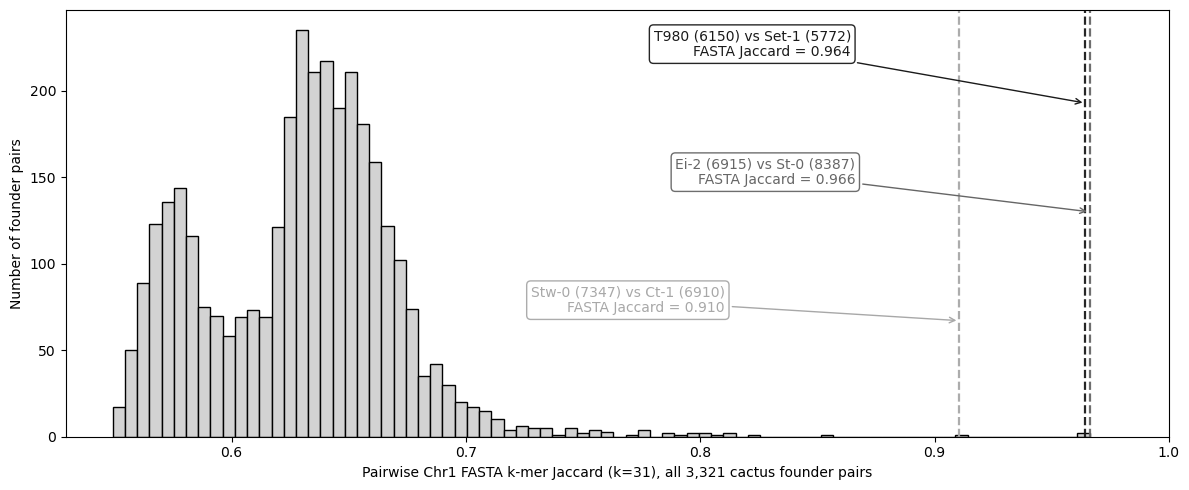

In [71]:
pairs_df = pd.read_csv(ROOT/'archive/exploration/jf_chr1/jaccard_pairs.tsv', sep='\t', dtype={'A':str,'B':str})

# Three suspect pairs (Tübingen Assembly_IDs), labelled with their Tübingen Accession_name / Accession_ID
SUSPECT_PAIRS_ASM = [
    (('100954','101003'), '#1a1a1a', 'T980 (6150) vs Set-1 (5772)'),       # 100954/101003
    (('100300','100692'), '#666666', 'Ei-2 (6915) vs St-0 (8387)'),         # 100300/100692
    (('100226','100645'), '#a8a8a8', 'Stw-0 (7347) vs Ct-1 (6910)'),        # 100226/100645
]
def keypair(a, b): return tuple(sorted([a, b]))
pairs_df['key'] = [keypair(a, b) for a, b in zip(pairs_df.A, pairs_df.B)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(pairs_df.jaccard, bins=80, color='lightgray', edgecolor='black')
ax.set_xlabel('Pairwise Chr1 FASTA k-mer Jaccard (k=31), all 3,321 cactus founder pairs')
ax.set_ylabel('Number of founder pairs')
ymax = ax.get_ylim()[1]
y_levels = [0.92, 0.62, 0.32]
xpad = [-0.10, -0.10, -0.10]
for k, ((a, b), color, label) in enumerate(SUSPECT_PAIRS_ASM):
    row = pairs_df[pairs_df['key'] == keypair(a, b)]
    if not len(row): continue
    j = float(row.iloc[0].jaccard)
    ax.axvline(j, color=color, lw=1.6, ls='--', alpha=0.95)
    ly = ymax * y_levels[k]
    lx = j + xpad[k]
    ax.annotate(f'{label}\nFASTA Jaccard = {j:.3f}',
                xy=(j, ly * 0.85),
                xytext=(lx, ly),
                fontsize=10, color=color, ha='right', va='center',
                bbox=dict(facecolor='white', edgecolor=color, alpha=0.95, boxstyle='round,pad=0.3'),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.0))
ax.set_xlim(left=min(pairs_df.jaccard) - 0.02, right=1.0)
plt.tight_layout()
plt.show()


## Plot 2 — Half-and-half heatmap: cactus FASTA Jaccard (upper) vs 1001G genotype Jaccard (lower)

Same 82-cactus-founder ordering on both halves, derived from hierarchical clustering on the cactus distances. Two cactus-only Accession_IDs (**6910** Ct-1, **7275** No-0) are not in GrENE-Net 231 and produce a gray cross in the lower half (their axis labels are highlighted in red). Suspect pairs use the same grey scheme as Plot 1.

**Diagnostic rule of thumb:**
- *Bright in BOTH halves* → either real close relatives or upstream labeling issue (concordant — not cactus-specific)
- *Bright in upper / pale in lower* → cactus says duplicate while 1001G says distinct (discordant — cactus-pipeline-specific anomaly)

In [ ]:
# Genotype-set Jaccard for the 82 cactus founders.  After Fernando's email
# (2026-05-14), we translate Tübingen's arapheno-alternate IDs to the 1001G-genotyped
# IDs ONLY for the cross-validation lookup (same biological sample, two valid IDs).

ARA_ALT_TO_1001G = {'6910': '7067', '7275': '7273'}   # Ct-1, No-0

d = np.load(ROOT/'_tmp_grenenet_chr1_snp_gt.npz', allow_pickle=True)
gt_all = d['gt']
samples_1001g = list(np.asarray(d['samples']).astype(str))

cactus = pd.read_csv(ROOT/'archive/exploration/jf_chr1/jaccard_pairs.tsv', sep='\t', dtype={'A':str,'B':str})
mapping = pd.read_csv(ROOT/'data/sv_panel_to_accession_id.tsv', sep='\t', dtype=str)
asm2acc = dict(zip(mapping.Assembly_ID, mapping.Accession_ID))
cactus['accA'] = cactus['A'].map(asm2acc)
cactus['accB'] = cactus['B'].map(asm2acc)
all_82 = sorted(set(cactus.accA) | set(cactus.accB))

# Accession_ID (display, from MAIN_LIST) -> Accession_ID used in 1001G genotype panel
acc_disp_to_1001g = {v: ARA_ALT_TO_1001G.get(v, v) for v in all_82}
in_1001g_acc      = sorted(set(acc_disp_to_1001g.values()) & set(samples_1001g))
print(f'82 cactus accessions; after arapheno-alternate translation, {len(in_1001g_acc)} have 1001G data')

# Build the GT-Jaccard matrix over the translated IDs
idx_sub = [samples_1001g.index(a) for a in in_1001g_acc]
sub_gt = gt_all[:, idx_sub]
A = (sub_gt == 1).astype(np.float32)
M = (sub_gt != 2).astype(np.float32)
both    = A.T @ A
sum_a_co = A.T @ M
either   = sum_a_co + sum_a_co.T - both
with np.errstate(divide='ignore', invalid='ignore'):
    jac_1001g = np.where(either > 0, both / either, np.nan)
np.fill_diagonal(jac_1001g, np.nan)
acc1001g2i = {a: i for i, a in enumerate(in_1001g_acc)}

# Key each cactus pair (display IDs) to its 1001G Jaccard value (translated IDs)
def keypair(a, b): return tuple(sorted([a, b]))
records = []
for i, a in enumerate(all_82):
    for j, b in enumerate(all_82):
        if i >= j: continue
        ia = acc_disp_to_1001g.get(a); ib = acc_disp_to_1001g.get(b)
        if ia in acc1001g2i and ib in acc1001g2i:
            records.append((a, b, jac_1001g[acc1001g2i[ia], acc1001g2i[ib]]))
df_1001g = pd.DataFrame(records, columns=['accA','accB','jaccard_1001g'])
df_1001g['key'] = [keypair(a, b) for a, b in zip(df_1001g.accA, df_1001g.accB)]
cactus['key']   = [keypair(a, b) for a, b in zip(cactus.accA,   cactus.accB)]

merged = cactus[['accA','accB','key','jaccard']].rename(columns={'jaccard':'jaccard_cactus'}).merge(
    df_1001g[['key','jaccard_1001g']], on='key', how='left'
)
print(f'82x82 cactus pairs: {len(merged)} | with 1001G genotype Jaccard: {merged.jaccard_1001g.notna().sum()}')

# Load the consolidated flag list
flag_df = pd.read_csv(ROOT/'data/flag_list.tsv', sep='\t', dtype=str)
EXCLUDE_IDS = set(flag_df[flag_df.Status == 'exclude'].Accession_ID)
QUALITY_IDS = set(flag_df[flag_df.Status == 'flag-quality'].Accession_ID)
AMBIG_IDS   = set(flag_df[flag_df.Status == 'flag-ambiguous-pair'].Accession_ID)
print(f'EXCLUDE: {sorted(EXCLUDE_IDS)}')
print(f'flag-quality: {sorted(QUALITY_IDS)}')
print(f'flag-ambiguous-pair: {sorted(AMBIG_IDS)}')

print()
print('Suspect-pair Jaccards (after arapheno-alternate translation for 1001G lookup):')
for a, b in [('5772','6150'), ('6915','8387'), ('7347','6910')]:
    row = merged[merged['key'] == keypair(a, b)]
    if len(row):
        r = row.iloc[0]
        print(f'  {a:>4s} vs {b:<4s}: cactus k-mer = {r.jaccard_cactus:.4f}   |   1001G GT = {r.jaccard_1001g:.4f}')


In [ ]:
# Half-and-half heatmap with axis labels color-coded by flag category:
#   red bold  = EXCLUDE
#   orange    = quality flag (Fernando Best_for_Moi="?")
#   purple    = ambiguous pair member (concordant anomalous closeness in both pipelines)
#   black     = clean
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

SUSPECT_PAIRS = [
    (('5772','6150'), '#1a1a1a', 'T980 (6150) vs Set-1 (5772) — 100954/101003'),
    (('6915','8387'), '#666666', 'Ei-2 (6915) vs St-0 (8387) — 100300/100692'),
    (('7347','6910'), '#a8a8a8', 'Stw-0 (7347) vs Ct-1 (6910) — 100226/100645'),
]

n = len(all_82)
acc2i = {a: i for i, a in enumerate(all_82)}
M_cactus = np.full((n, n), np.nan, dtype=np.float32)
M_1001g  = np.full((n, n), np.nan, dtype=np.float32)
for _, r in merged.iterrows():
    i, j = acc2i[r.accA], acc2i[r.accB]
    M_cactus[i, j] = M_cactus[j, i] = r.jaccard_cactus
    if pd.notna(r.jaccard_1001g):
        M_1001g[i, j] = M_1001g[j, i] = r.jaccard_1001g

D = 1.0 - np.nan_to_num(M_cactus, nan=0.5); np.fill_diagonal(D, 0)
order = leaves_list(linkage(squareform(D, checks=False), method='average'))
names_ord = np.array(all_82)[order]
Mc = M_cactus[order][:, order]
Mg = M_1001g[order][:, order]
upper = np.triu(np.ones((n, n), dtype=bool), k=1)
lower = np.tril(np.ones((n, n), dtype=bool), k=-1)
Mc_u = np.where(upper, Mc, np.nan)
Mg_l = np.where(lower, Mg, np.nan)

fig = plt.figure(figsize=(13, 11))
ax = fig.add_axes([0.06, 0.06, 0.78, 0.88])
cax_c = fig.add_axes([0.88, 0.53, 0.022, 0.41])
cax_g = fig.add_axes([0.88, 0.06, 0.022, 0.41])
im_c = ax.imshow(Mc_u, cmap='Reds',  vmin=0.55, vmax=1.0, aspect='equal', interpolation='nearest')
im_g = ax.imshow(Mg_l, cmap='Blues', vmin=0.20, vmax=1.0, aspect='equal', interpolation='nearest')

ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(names_ord, rotation=90, fontsize=6)
ax.set_yticklabels(names_ord, fontsize=6)
ax.plot([-0.5, n - 0.5], [-0.5, n - 0.5], color='black', lw=0.8, alpha=0.7)

# Color tick labels by flag category
EXCLUDE_COLOR = '#cc0000'
QUALITY_COLOR = '#e67e00'
AMBIG_COLOR   = '#7733aa'
def style_tick(tick, lbl):
    if lbl in EXCLUDE_IDS:
        tick.set_color(EXCLUDE_COLOR); tick.set_fontweight('bold')
    elif lbl in QUALITY_IDS:
        tick.set_color(QUALITY_COLOR)
    elif lbl in AMBIG_IDS:
        tick.set_color(AMBIG_COLOR)
for tick, lbl in zip(ax.get_xticklabels(), names_ord): style_tick(tick, lbl)
for tick, lbl in zip(ax.get_yticklabels(), names_ord): style_tick(tick, lbl)

def cell_box(a, b, color, lw=1.4):
    if a in names_ord and b in names_ord:
        ia = int(np.where(names_ord == a)[0][0])
        ib = int(np.where(names_ord == b)[0][0])
        for x, y in [(ia, ib), (ib, ia)]:
            ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, fill=False, edgecolor=color, lw=lw))

for (a, b), color, _ in SUSPECT_PAIRS:
    cell_box(a, b, color)

cb_c = fig.colorbar(im_c, cax=cax_c)
cb_c.set_label('Cactus k-mer Jaccard (upper)', fontsize=10)
cb_c.ax.tick_params(labelsize=9)
cb_g = fig.colorbar(im_g, cax=cax_g)
cb_g.set_label('1001G GT Jaccard (lower)', fontsize=10)
cb_g.ax.tick_params(labelsize=9)

# Two-part legend: suspect-pair boxes + axis-label colour legend
suspect_handles = [Patch(facecolor='none', edgecolor=col, lw=1.4, label=lab)
                   for _, col, lab in SUSPECT_PAIRS]
axis_handles = [
    Line2D([0], [0], color=EXCLUDE_COLOR, lw=0, marker='s', markerfacecolor=EXCLUDE_COLOR, markersize=8, label='EXCLUDE (Fernando "?" + our anomaly)'),
    Line2D([0], [0], color=QUALITY_COLOR, lw=0, marker='s', markerfacecolor=QUALITY_COLOR, markersize=8, label='flag-quality (Fernando Best_for_Moi="?")'),
    Line2D([0], [0], color=AMBIG_COLOR,   lw=0, marker='s', markerfacecolor=AMBIG_COLOR,   markersize=8, label='flag-ambiguous-pair (concordant anomalous closeness)'),
]
leg1 = ax.legend(handles=suspect_handles, loc='lower right', fontsize=8, framealpha=0.95, title='Suspect pairs')
ax.add_artist(leg1)
ax.legend(handles=axis_handles, loc='upper left', fontsize=8, framealpha=0.95, title='Axis label colours')

plt.show()


## Interpretation

The three pairs that came out of the k-mer Jaccard analysis split into two mechanistic categories now that we have Fernando's `Best_for_Moi` annotations:

**(A) Assembly-quality issue — 101003 (Set-1 / 5772) vs 100954 (T980 / 6150).** Cactus k-mer J=0.964 (at the same-assembly threshold), 1001G genotype J=0.300 (in the bulk). The two pipelines disagree. Fernando independently flags **101003 with `Best_for_Moi="?"` and `Reason="Heterozygosity: Too many variants"`** — an over-heterozygous assembly carries an inflated variant set that can produce spuriously high k-mer overlap with other assemblies. Both the k-mer signature (discordant with 1001G) and Fernando's independent QC point at 101003 as a corrupted assembly. **Action: exclude 101003** until a re-assembly is available. T980 (100954) is clean — it just happens to be the second-hit victim of 101003's over-heterozygous k-mer set.

**(B) Concordant biological / sample-handling closeness — Ei-2 / St-0 and Stw-0 / Ct-1.** Both pairs show anomalous closeness in *both* pipelines (cactus k-mer + 1001G GT Jaccard), so the closeness predates either assembly pipeline. Fernando flags none of the four assemblies as `?`. Two non-exclusive interpretations: (i) genuine close relatedness at the seed level (sister lines or duplicate seed stocks under two names), or (ii) DNA-prep mix-up upstream of the short-read / long-read paths diverging. Needs Fernando's input on seed source / DNA prep before deciding whether to drop either side.

## Outputs

- `data/exclude_list.txt` — Assembly_IDs to drop (currently just 101003).
- `data/flag_list.tsv` — full table with Status (`exclude` / `flag-quality` / `flag-ambiguous-pair`) and per-row Reason.
- Heatmap PNG: `archive/exploration/jf_chr1/cactus_vs_1001g_jaccard_heatmap.png`
- Histogram PNG: `archive/exploration/jf_chr1/cactus_jaccard_histogram.png`


## Draft email for Fernando

> **To:** Fernando Rabanal (MPI Tübingen)
> **From:** Tatiana Bellagio (Carnegie / Exposito-Alonso lab)
> **Subject:** QC follow-up on the 1001G+ long-read panel — two concordant pairs remaining, Set-1 confirmed
>
> Hi Fernando,
>
> Thanks for the `Best_for_Moi` list and the email — it cleared up the Ct-1 / No-0 arapheno-double-ID question (we now translate 6910→7067 and 7275→7273 for the 1001G short-read lookup only) and resolved one of our three suspect pairs cleanly. We confirmed the 7 `?` assemblies in our 82-panel and made a `flag_list.tsv` capturing all this on our side.
>
> **Set-1 / T980 — explained by your heterozygosity flag.** Our pairwise Chr1 k-mer Jaccard (k=31, canonical) flagged 101003 (Set-1, 5772) and 100954 (T980, 6150) as anomalously similar (J=0.964, top tier across all 3,321 pairs). The 1001G short-read genotype Jaccard for Set-1 vs T980 is 0.300 — squarely in the bulk, i.e., normal between-accession distance. Discordant pattern. Your `Best_for_Moi="?"` flag for **101003 with `Heterozygosity: Too many variants`** is fully consistent: an over-heterozygous assembly carries an inflated variant set that spuriously elevates k-mer overlap with unrelated assemblies. We are excluding 101003 from downstream analyses. No action needed from you on this one.
>
> **Two concordant pairs that still need your input** — both pairs show anomalous closeness in *both* pipelines (k-mer on the long-read FASTAs **and** 1001G short-read SNP data), so the closeness predates either assembly pipeline. None of the four assemblies has a `Best_for_Moi` flag:
>
> | Pair | Cactus k-mer Jaccard | 1001G genotype Jaccard | Bulk distribution |
> |---|---:|---:|---|
> | **100300 (Ei-2, 6915) vs 100692 (St-0, 8387)** | **0.966** | **0.935** | cactus p1–p99 = 0.56–0.83; 1001G p1–p99 ≈ 0.23–0.52 |
> | **100226 (Stw-0, 7347) vs 100645 (Ct-1, 6910)** | **0.911** | **0.697** | (same context) |
>
> Both pairs jump out of the bulk in both pipelines — they look like the same biological sample to both long-read and short-read. Possible explanations:
> 1. The accessions are genuinely near-identical (sister lines, or two seed stocks under two names that trace back to a single ancestor)
> 2. DNA was mixed up at a step upstream of where the short-read and long-read paths diverged (e.g., a seed handling / DNA prep error)
>
> Could you check your seed-source records for those four accessions? Specifically: were the seed batches for "Ei-2" and "St-0" obtained from independent stock sources, or could they share an origin? Same question for "Stw-0" and "Ct-1". If you have any internal genotyping or phenotypic notes that distinguish these accessions, that would help us decide whether to drop one side of each pair or keep both with a "near-identical" caveat.
>
> Reproducibility / reference paths on our side:
> - Source FASTAs: `20260209_Exposito-Alonso/chr_only/{100300,100692,100226,100645,101003,100954}.chr.fa`
> - Tübingen MAIN_LIST: `data/ASSEMBLIES_Best_version_of_dataset.xlsx`
> - Best_for_Moi list you sent: `data/request_assemblies_for_Moi.csv`
> - 1001G short-read VCF: `xwu/GrENE_net/greneNet_final_v1.1.recode.vcf`
> - Pipeline: `jellyfish count -m 31 -C` per FASTA → pairwise `jellyfish merge`, Jaccard = |A∩B|/|A∪B|.
>
> Happy to share the full diagnostic notebook (two plots — distribution histogram and half-and-half cactus-vs-1001G heatmap, with axis labels color-coded by your `Best_for_Moi` status) or to walk through it on a call if helpful.
>
> Thanks again!
> Tatiana
